# [초미니미니 프로젝트] 유튜브 댓글 텍스트 분석
맛집 추천 유튜버
reveiw : 댓글
likes : 좋아요 수
category : 음식 종류(한식, 양식, 일식, 등)
start : 댓글 수집 시작 날짜
end : 댓글 수집 종료 날짜
answered : 대댓글
Q. likes(좋아요)가 100건 이상인 데이터만 확인
Q. 어느 카테고리에서 가장 많이 likes를 받았나
- 카테고리 별 likes 랭킹
- 카테고리 별 likes 합계 집계 후 시각화
Q. 시작날짜 별 투표수 집계 => "likes를 많이 받은 날"
Q. likes EDA
-----------------------
Q. 관심 키워드 들어간 댓글 추출 후 
ex) 치킨 | 한식 | 
Q. 명사 기반 워드클라우드
- 형태소 분석 
Q. 기타 다양한 분석
-----------------------
오후
토픽 모델링, LDA


In [37]:
#라이브러리 불러오기
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import koreanize_matplotlib

import os
import platform

# 그래프에 retina display 적용
%config InlineBackend.figure_format = 'retina'

import konlpy
import soynlp

# 워닝 무시
import warnings
warnings.filterwarnings('ignore')

In [7]:
%pwd


'C:\\Users\\jg\\Desktop\\부트캠프\\text_mining'

In [17]:
df= pd.read_csv(f"data/korean_youtube_food_comments_with_category.csv", 
                        # index_col="article_id",
                       parse_dates=['start', 'end'])
print(df.shape)
df

(1000, 6)


,start,end,category,answered,likes,review
0,2024-05-20,2024-05-21,한식,7,71,다음에는 홍대 다른 맛집도 소개해주세요!
1,2024-10-06,2024-10-06,한식,18,216,합정 가면 여기 꼭 가봐야겠네요! 떡볶이 진짜 맛있어 보입니다.
2,2024-04-21,2024-04-22,한식,16,308,강남 가면 여기 꼭 가봐야겠네요! 삼겹살 진짜 맛있어 보입니다.
3,2024-10-06,2024-10-09,중식,7,229,마라탕 좋아하는데 이런 맛집이 있었다니!
4,2024-01-04,2024-01-05,한식,13,174,와 칼국수 진짜 맛있어 보이네요. 침 고입니다.
...,...,...,...,...,...,...
995,2024-01-15,2024-01-16,동남아,6,169,오늘 저녁 메뉴는 쌀국수로 결정했습니다.
996,2024-09-02,2024-09-05,한식,1,330,보쌈 비주얼 미쳤네요… 다음 주말에 가볼게요!
997,2024-08-23,2024-08-25,양식,14,401,오늘 저녁 메뉴는 피자로 결정했습니다.
998,2024-01-29,2024-01-31,일식,18,371,영상 퀄리티도 좋고 정보도 좋아요.


In [22]:
#  likes(좋아요)가 100건 이상인 데이터만 확인
df_high_likes = df[(df['likes'] >=100)].copy()
df_high_likes

,start,end,category,answered,likes,review
1,2024-10-06,2024-10-06,한식,18,216,합정 가면 여기 꼭 가봐야겠네요! 떡볶이 진짜 맛있어 보입니다.
2,2024-04-21,2024-04-22,한식,16,308,강남 가면 여기 꼭 가봐야겠네요! 삼겹살 진짜 맛있어 보입니다.
3,2024-10-06,2024-10-09,중식,7,229,마라탕 좋아하는데 이런 맛집이 있었다니!
4,2024-01-04,2024-01-05,한식,13,174,와 칼국수 진짜 맛있어 보이네요. 침 고입니다.
5,2024-06-21,2024-06-21,한식,2,194,영상 보고 바로 저장했습니다. 순대국 먹으러 이태원 가야겠어요.
...,...,...,...,...,...,...
995,2024-01-15,2024-01-16,동남아,6,169,오늘 저녁 메뉴는 쌀국수로 결정했습니다.
996,2024-09-02,2024-09-05,한식,1,330,보쌈 비주얼 미쳤네요… 다음 주말에 가볼게요!
997,2024-08-23,2024-08-25,양식,14,401,오늘 저녁 메뉴는 피자로 결정했습니다.
998,2024-01-29,2024-01-31,일식,18,371,영상 퀄리티도 좋고 정보도 좋아요.


In [23]:
# 어느 카테고리에서 가장 많이 likes를 받았나
# 카테고리 별 likes 랭킹
# 카테고리 별 likes 합계 집계 후 시각화

In [25]:
df.head(3)

,start,end,category,answered,likes,review
0,2024-05-20,2024-05-21,한식,7,71,다음에는 홍대 다른 맛집도 소개해주세요!
1,2024-10-06,2024-10-06,한식,18,216,합정 가면 여기 꼭 가봐야겠네요! 떡볶이 진짜 맛있어 보입니다.
2,2024-04-21,2024-04-22,한식,16,308,강남 가면 여기 꼭 가봐야겠네요! 삼겹살 진짜 맛있어 보입니다.


In [34]:
# 날짜 컬럼을 제외
df_nodate = df.drop(columns=['start', 'end','review'])
df_nodate

,category,answered,likes
0,한식,7,71
1,한식,18,216
2,한식,16,308
3,중식,7,229
4,한식,13,174
...,...,...,...
995,동남아,6,169
996,한식,1,330
997,양식,14,401
998,일식,18,371


In [33]:
# 카테고리 별 likes 랭킹 (합계 집계)
category_likes = df.groupby('category')['likes'].sum().sort_values(ascending=False).reset_index()
print("--- 카테고리 별 likes 랭킹 ---")
print(category_likes)

--- 카테고리 별 likes 랭킹 ---
  category   likes
0       한식  139421
1       일식   38639
2       양식   37210
3       중식   13256
4       남미   13144
5      동남아   10263


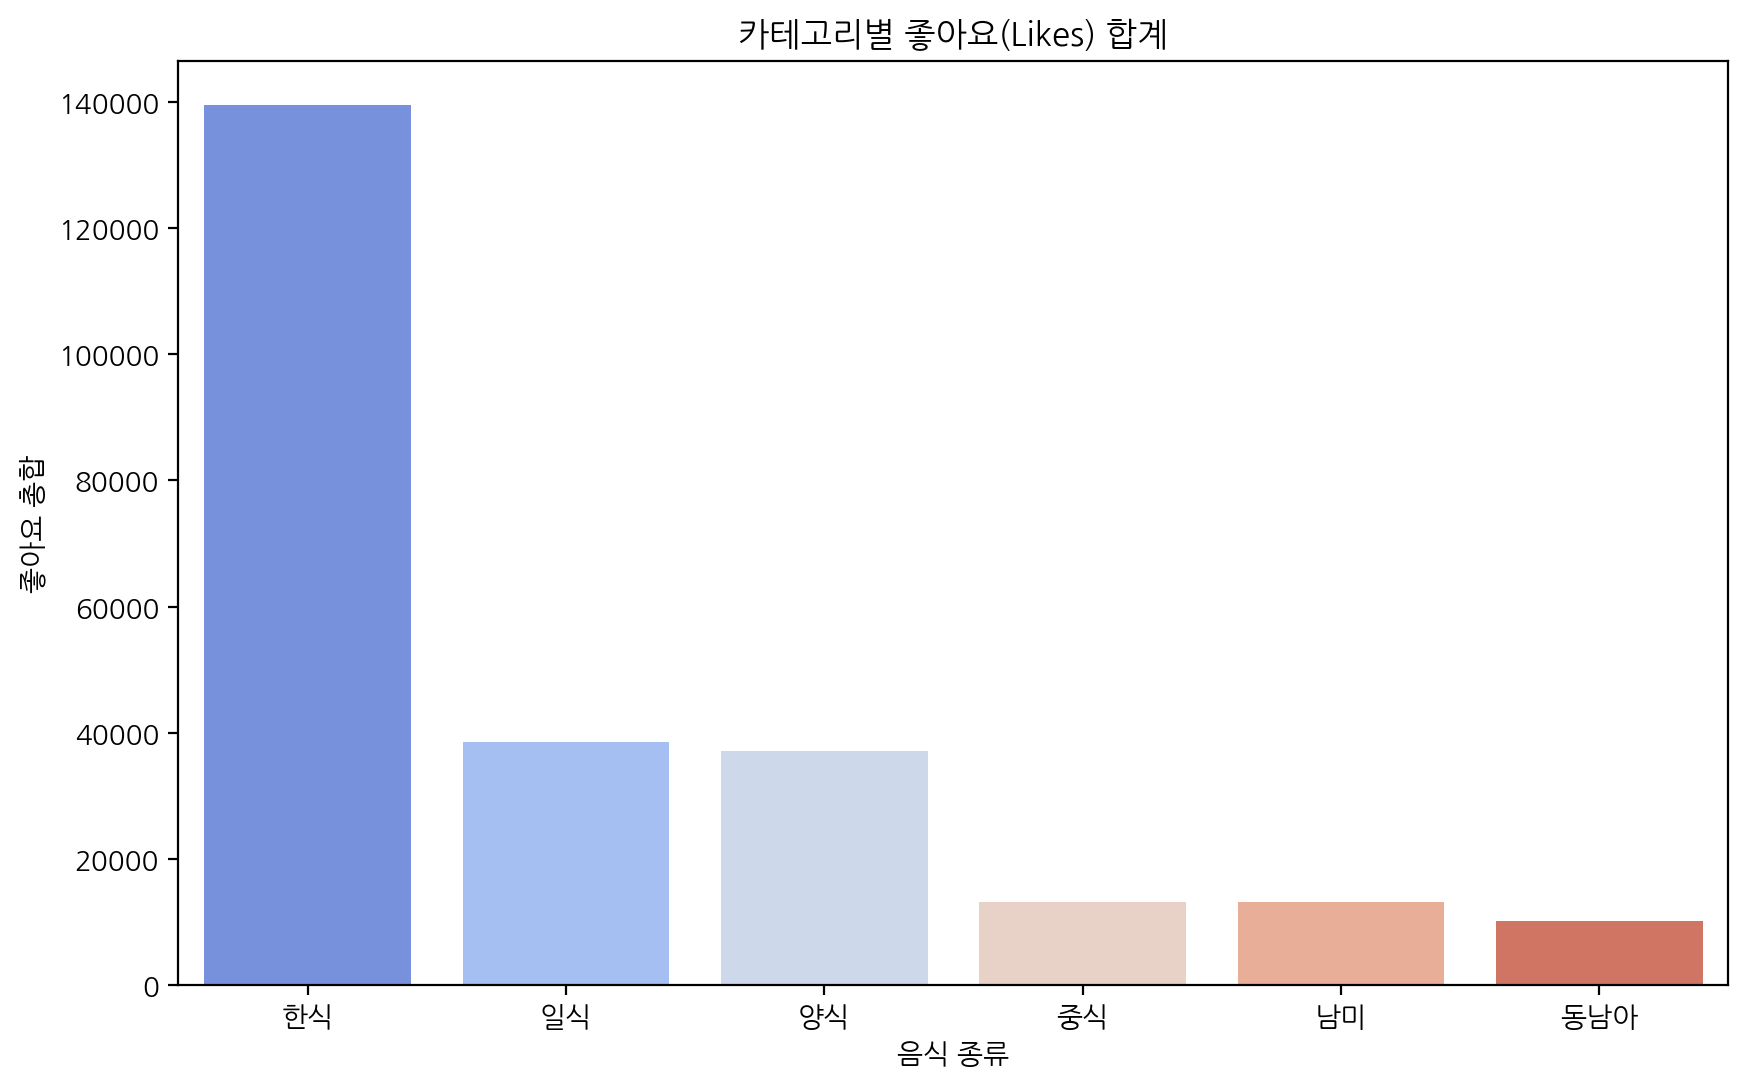

In [38]:
# 2. [Q] 카테고리 별 likes 합계 시각화
plt.figure(figsize=(10, 6))
sns.barplot(data=category_likes, x='category', y='likes', palette='coolwarm')
plt.title('카테고리별 좋아요(Likes) 합계')
plt.xlabel('음식 종류')
plt.ylabel('좋아요 총합')
plt.show()

In [40]:
 # 시작날짜 별 투표수 집계 => "likes를 많이 받은 날"
daily_likes = df.groupby('start')['likes'].sum().sort_values(ascending=False)
daily_likes.head()

start
2024-01-28    2186
2024-10-07    2093
2024-07-14    2079
2024-10-25    2003
2024-04-25    1922
Name: likes, dtype: int64

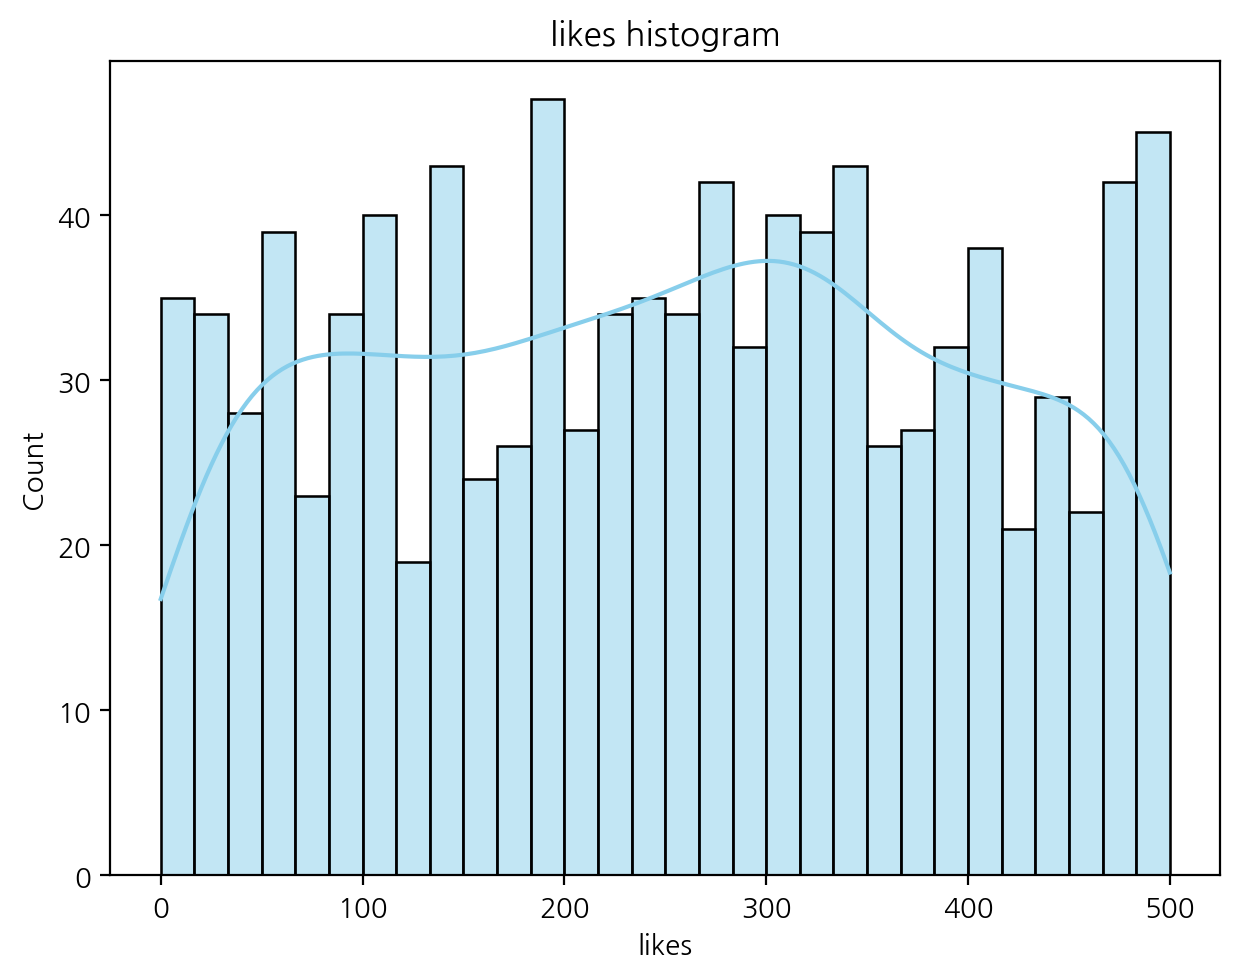

In [45]:
# likes EDA (데이터의 분포와 이상치 확인)
plt.figure(figsize=(12, 5))

# 히스토그램: 좋아요 수가 어느 범위에 몰려 있는지 확인
plt.subplot(1, 2, 1)
sns.histplot(df['likes'], bins=30, kde=True, color='skyblue')
plt.title('likes histogram')

plt.tight_layout()
plt.show()

# 텍스트마이닝

In [ ]:
# 관심 키워드 들어간 댓글 추출 후 
# ex) 치킨 | 한식 | 

# 명사 기반 워드클라우드
# - 형태소 분석 

# 기타 다양한 분석

In [47]:
from konlpy.tag import Okt
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter

In [48]:
# 1. 형태소 분석기 초기화
okt = Okt()

In [52]:
# 2. [Q] 관심 키워드(예: 치킨, 한식)가 들어간 댓글 추출
# 분석하고 싶은 키워드를 리스트에 넣으세요.
target_keywords = ['치킨', '한식', '떡볶이', '가성비']
keyword_df = df[df['review'].str.contains('|'.join(target_keywords))].copy()

print(f"--- 키워드 '{target_keywords}'가 포함된 댓글 수: {len(keyword_df)}개 ---")
print(keyword_df[['category', 'review']].head())

--- 키워드 '['치킨', '한식', '떡볶이', '가성비']'가 포함된 댓글 수: 50개 ---
   category                               review
1        한식  합정 가면 여기 꼭 가봐야겠네요! 떡볶이 진짜 맛있어 보입니다.
18       한식            치킨 비주얼 미쳤네요… 다음 주말에 가볼게요!
33       한식  압구정 가면 여기 꼭 가봐야겠네요! 치킨 진짜 맛있어 보입니다.
68       한식               오늘 저녁 메뉴는 떡볶이로 결정했습니다.
72       한식           와 떡볶이 진짜 맛있어 보이네요. 침 고입니다.


In [53]:
# 3. 명사 기반 형태소 분석
# 모든 리뷰를 하나의 텍스트로 합친 후 명사만 추출합니다.
all_reviews = " ".join(df['review'].tolist())
nouns = okt.nouns(all_reviews)

In [57]:
# 4. 불용어(Stopwords) 제거 
# 분석에 의미 없는 단어들을 제거합니다.
stopwords = ['여기', '진짜', '너무', '보고', '영상', '소개', '함께', '생각', '정도','포기']
unique_nouns = [n for n in nouns if len(n) > 1 and n not in stopwords]

In [58]:
# 5. 빈도수 집계 및 워드클라우드 시각화
noun_counts = Counter(unique_nouns)

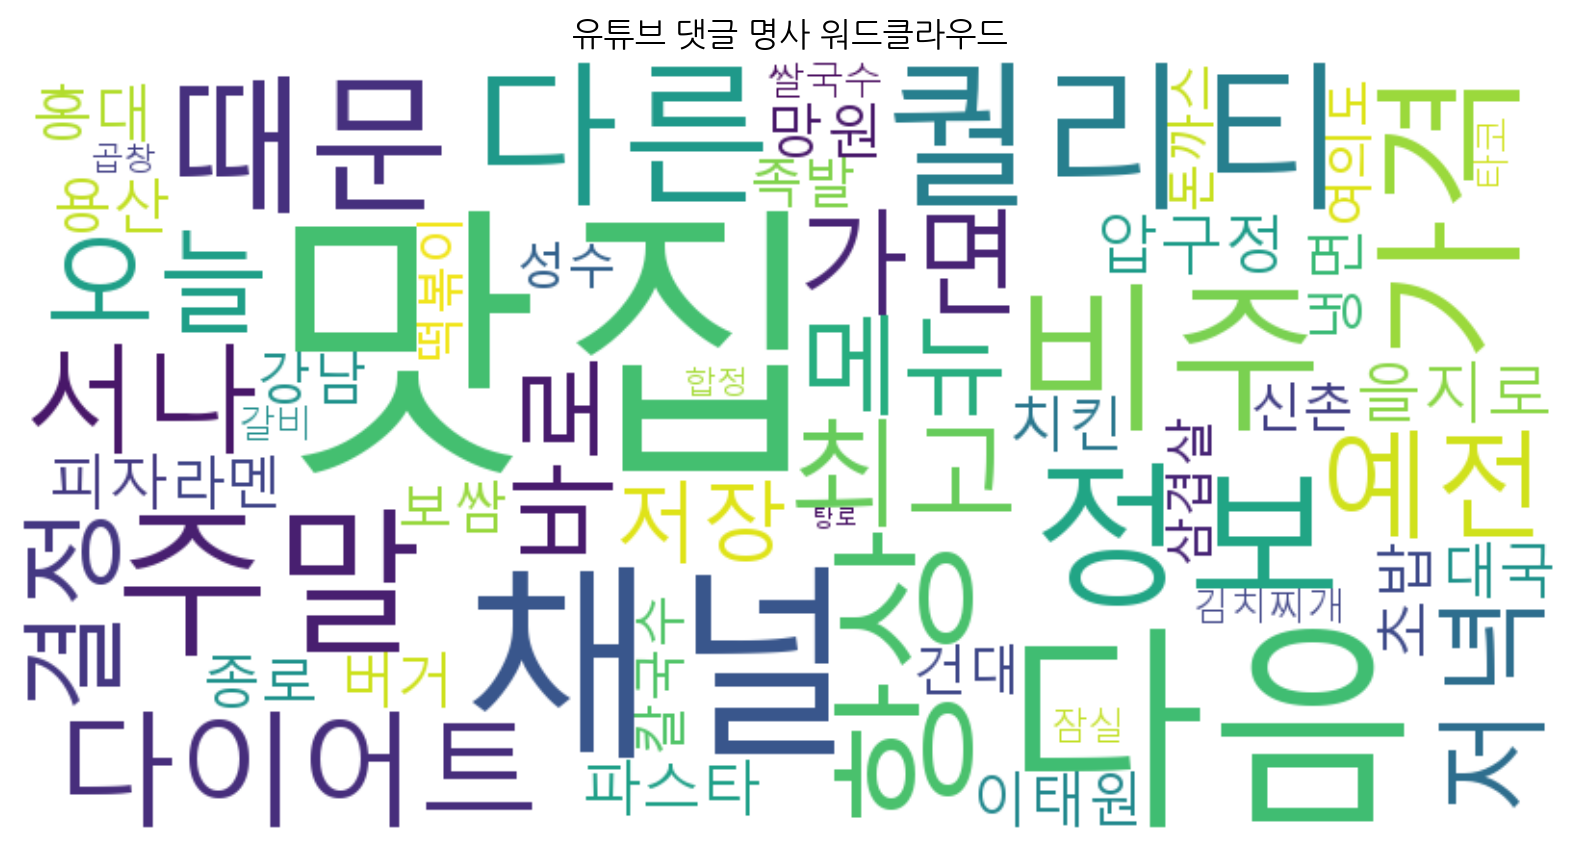

In [59]:
# 워드클라우드 생성
# (한글 폰트 경로를 본인 환경에 맞춰 설정해야 합니다. 예: 'NanumGothic.ttf')
wc = WordCloud(
    font_path='malgun', # 윈도우: 'malgun', 맥: 'AppleGothic'
    background_color='white',
    width=800,
    height=400
).generate_from_frequencies(noun_counts)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('유튜브 댓글 명사 워드클라우드')
plt.show()

### 추가 분석

상관계수(Correlation): -0.0052


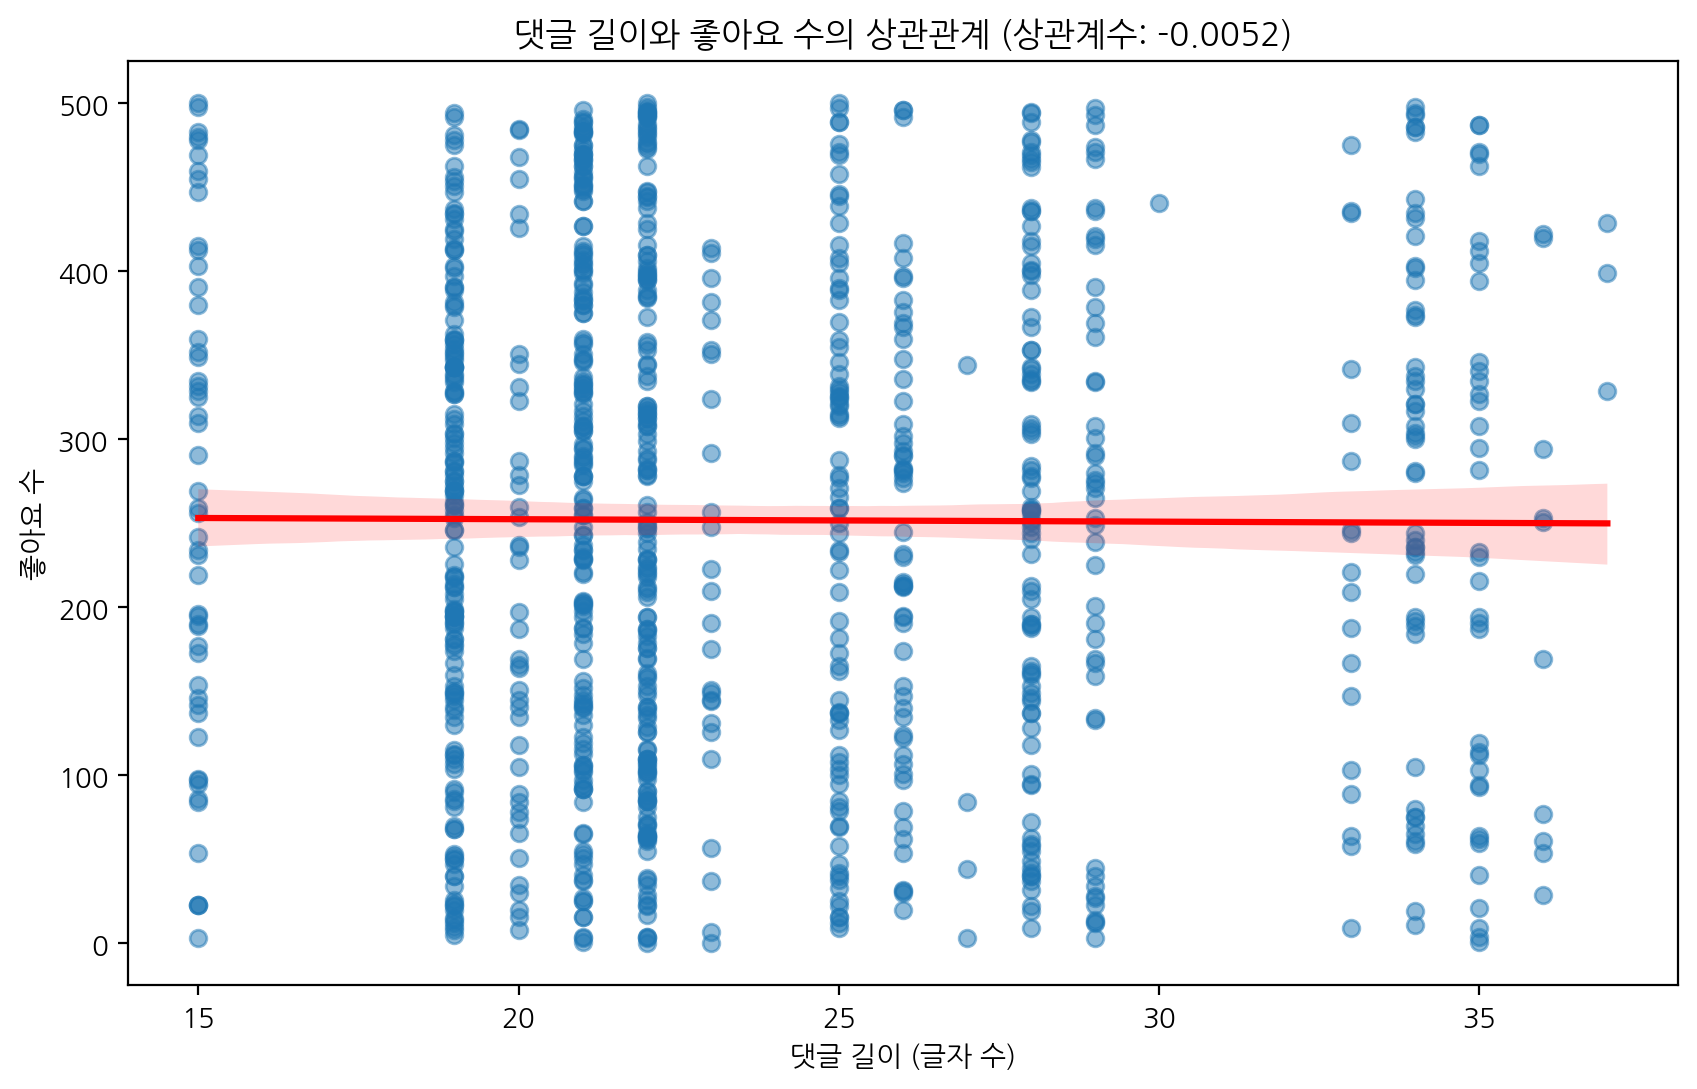

In [61]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 댓글 길이(글자 수) 컬럼 생성
df['review_len'] = df['review'].str.len()

# 2. 상관계수 계산
correlation = df['review_len'].corr(df['likes'])
print(f"상관계수(Correlation): {correlation:.4f}")

# 3. 시각화 (산점도와 회귀선)
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='review_len', y='likes', 
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title(f'댓글 길이와 좋아요 수의 상관관계 (상관계수: {correlation:.4f})')
plt.xlabel('댓글 길이 (글자 수)')
plt.ylabel('좋아요 수')
plt.show()